In [ ]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import pandas as pd


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);

In [ ]:
# --- Simulation config ---
T_HORIZON = 3600.0          # [s]  total simulation horizon
T = 1000           # number of time steps
DT = T_HORIZON / (T)   # fixed for all sims
t_fixed = np.linspace(0, T_HORIZON, T)    # fixed 'physical' grid

In [ ]:
# --- Data generation ---

translator = {
    'I': 'Current [A]',
    'V': 'Terminal voltage [V]',
    'cn': 'X-averaged negative particle concentration [mol.m-3]',
    'cp': 'X-averaged positive particle concentration [mol.m-3]',
    'cns': 'X-averaged negative particle surface concentration [mol.m-3]',
    'cps': 'X-averaged positive particle surface concentration [mol.m-3]',
    'ocv': 'Battery open-circuit voltage [V]',
}

translator_inv = {v: k for k, v in translator.items()}

data_cols = ['I', 'V', 'ocv']

def gen_cols(data_cols, translator=translator):
    '''Extracting variable names from translator dict for given data_cols'''
    return [translator[col] for col in data_cols]



def time_query(sol, t_fixed):
    t_end = sol["Time [s]"].entries[-1]
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    return t_query, valid

def observe_states(t_query, sol, model, data_cols):
    data = pd.DataFrame(index=t_query)
    cols = gen_cols(data_cols)
    for col in cols:
        data[translator_inv[col]] = sol.observe(model.variables[col])(t_query)
    return data

def get_vals_DC(I0,data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_DC1(I0, T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_pulse(data_cols=data_cols):
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(T_HORIZON, DT, RNG=None)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_GRF(data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_GRF(T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model


def gen_data(B, data_cols, currents='DC', I_low=0.25, I_high=1.0, seed=None):
    '''Generate trajectories with shape (B, T, D)'''

    rng = np.random.default_rng(seed)

    dot_cols = [f"{k}_dot" for k in data_cols if k in ['cn','cp']]
    all_cols = data_cols + ['dI'] + dot_cols + ['valid']

    D = len(all_cols)

    X = np.zeros((B, T, D))
    var_index = {k:i for i,k in enumerate(all_cols)}

    for b in trange(B):

        if currents == 'DC':
            data, valid_b, param, sol, model = get_vals_DC(float(rng.uniform(I_low, I_high)))
        elif currents == 'pulse':
            data, valid_b, param, sol, model = get_vals_pulse()
        elif currents == 'GRF':
            data, valid_b, param, sol, model = get_vals_GRF()
        else:
            raise ValueError("Invalid current type")

        # base variables
        for col in data_cols:
            X[b, :, var_index[col]] = data[col].values

        # dI
        if 'I' in data_cols:
            I = data['I'].values
            dI = np.zeros_like(I)
            dI[1:] = np.diff(I)
            X[b, :, var_index['dI']] = dI

        # derivatives
        for col in ['cn','cp']:
            if col in data_cols:
                x = data[col].values
                xdot = np.zeros_like(x)
                xdot[:-1] = np.diff(x) / DT
                xdot[-1] = xdot[-2]
                X[b, :, var_index[f"{col}_dot"]] = xdot

        # valid mask
        X[b, :, var_index['valid']] = valid_b.astype(float)

    return X, var_index


In [ ]:
X, var_index = gen_data(2, data_cols, currents='DC', I_low=0.25, I_high=1.0, seed=42)
print("Data shape:", X.shape)
print("Variable index:", var_index)

100%|██████████| 2/2 [00:02<00:00,  1.48s/it]

Data shape: (2, 1000, 5)
Variable index: {'I': 0, 'V': 1, 'ocv': 2, 'dI': 3, 'valid': 4}


In [ ]:
# --- Load data ---
def load_data(path, var_index = var_index):
    with np.load(path) as d:
        X = d['X']  # replace 'X' with the actual key if different

    data = {var: X[:, :, idx] for var, idx in var_index.items()}
    return data


path = f'data_PHNN/data_c_DC_dt_{T}.npz'
D = load_data(path)
I = D['I']; V = D['V']; ocv = D['ocv']
B = I.shape[0]

D['valid'] = D['valid'].astype(bool)

In [ ]:
# --- Normalization ---
stats = {}
def compute_stats(D=D,data_cols=data_cols):
    for name in data_cols:
        stats[name] = (float(D[name].ravel()[D['valid'].ravel()].mean()), float(max(D[name].ravel()[D['valid'].ravel()].std(), 1e-8)))  # Avoid zero std
    return stats

def transform(arr, name):
    mean, std = stats[name]
    return (arr - mean) / std

def inverse_transform(arr, name):
    mean, std = stats[name]
    return arr * std + mean
    
stats = compute_stats()

# Normalize

I_n = transform(I, 'I')
V_n = transform(V, 'V')
ocv_n = transform(ocv, 'ocv')

In [ ]:
# --- Split data ---
x = torch.tensor(np.stack([I_n], axis=-1), dtype=torch.float32) # (B, T, 4)
print(x.shape)
y = torch.tensor(np.stack([V_n, ocv_n], axis=-1), dtype=torch.float32)
mask = torch.tensor(D['valid'], dtype=torch.float32)

split = int(0.8 * B)
def _split(arr):
    return arr[:split], arr[split:]

def _split_flat(arr):
    return arr[:split].flatten(0,1), arr[split:].flatten(0,1)   # Same as reshape(B * T, C)    # (B*T, 4)

# Flatten time dimension for training and split
x_train, x_test = _split_flat(x)        
y_train, y_test = _split_flat(y)
mask_train, mask_test = _split_flat(mask)

# # Unflattened
x_train_batch, x_test_batch = _split(x) # (B, T, 4)
y_train_batch, y_test_batch = _split(y)
mask_train_batch, mask_test_batch = _split(mask)

# Un-normalized for plotting
I_train,      I_test      = _split(I)
V_train,      V_test      = _split(V)
ocv_train,    ocv_test    = _split(ocv)
mask_train_plot, mask_test_plot = _split(D['valid'])

batch_size_small = int(B/4)
# batch_size_large = int(B*T/4)
train_loader_batch = DataLoader(TensorDataset(x_train_batch, y_train_batch, mask_train_batch), batch_size=batch_size_small, shuffle=True)
# train_loader_flat = DataLoader(TensorDataset(x_train, y_train, mask_train), batch_size=batch_size_large, shuffle=True)

torch.Size([100, 1000, 1])


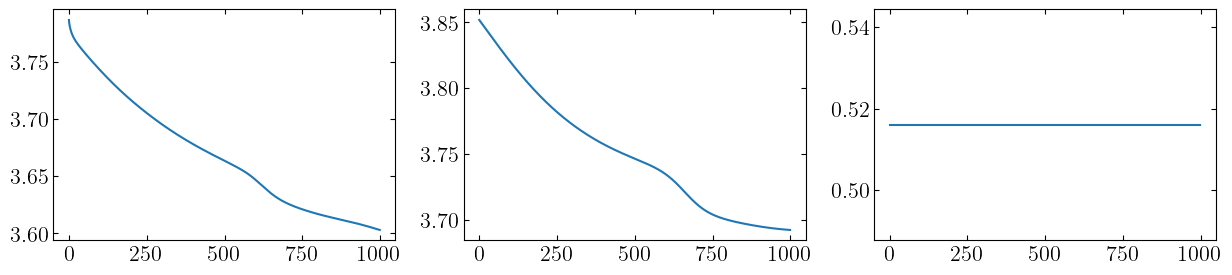

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))
axes[0].plot(V_test[0, :], label='cn')
axes[1].plot(ocv_test[0, :], label='valid')
axes[2].plot(I_test[0, :], label='dI')


In [ ]:
# Parameter identification via gradient descent
class BatteryPHNN_SOC(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        # SOC in [0,1] → 3 positive parameters
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 3)
        )
        self.Q_n = nn.Parameter(torch.tensor(3600.0))  # nominal capacity [As], learnable

    def forward(self, soc):
        # soc: (B,) or (B, 1)
        if soc.dim() == 1:
            soc = soc.unsqueeze(-1)   # (B, 1)
        return nn.functional.softplus(self.net(soc))   # (B, 3)

model = BatteryPHNN_SOC()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

def dynamics(pred, q1, I_t):
    R1 = pred[:, 1]   # (B,)
    C1 = pred[:, 2]   # (B,)
    dQ  = - I_t
    dq1 = I_t - q1 / (R1 * C1)
    return torch.stack([dQ, dq1], dim=1)


def evolver(pred, x, I_t, dt):
    '''
    x   : (B, 2)   [Q, q1]
    I_t : (B,)     current [A]
    dt  : float
    '''
    Q  = x[:, 0]   # (B,)
    q1 = x[:, 1]   # (B,)
    R1 = pred[:, 1]   # (B,)
    C1 = pred[:, 2]   # (B,)

    # Q update — explicit (I does not depend on Q)
    Q_new  = Q - I_t * dt

    # q1 update — implicit, closed form, unconditionally stable
    tau    = R1 * C1                   # scalar, RC time constant
    q1_new = (q1 + dt * I_t) / (1.0 + dt / tau)   # (B,)
    return torch.stack([Q_new, q1_new], dim=1)     # (B, 2)


def ph_rollout_soc(model, x0, I_phys, ocv_phys, dt, Q_0):
    """
    x0    : (B, 2)   [Q0 in Coulombs, q1_0=0]
    Q_0   : (B,)     initial charge, e.g. from coulomb counting or assumed full
    """
    x = x0
    B_b, T_steps = I_phys.shape
    V_pred = []

    for t in range(T_steps):
        I_t   = I_phys[:, t]         # (B,)
        ocv_t = ocv_phys[:, t]       # (B,)

        # SOC from current state
        Q  = x[:, 0]                 # (B,)  charge remaining
        soc = (Q_0 + Q) / model.Q_n  # (B,)  Q is negative (discharge)
        soc = soc.clamp(0.0, 1.0)   # safety clip

        # Parameters as function of SOC
        params = model(soc)          # (B, 3)
        R0 = params[:, 0]
        R1 = params[:, 1]
        C1 = params[:, 2]

        # Output
        q1 = x[:, 1]
        V1 = q1 / C1
        V_t = ocv_t - V1 - R0 * I_t
        V_pred.append(V_t)

        x = evolver(params, x, I_t, dt)

    return torch.stack(V_pred, dim=1)   # (B, T)

def masked_mse(pred, target, mask):
    err = (pred - target) ** 2    # (B, T)
    return (err * mask).sum() / (mask.sum() * 2)

def training(epochs=10):
    history = {"loss": [], "time per ep": []}
    for ep in range(epochs):
        model.train()
        tot_ep_loss = 0.0
        start_t = time.perf_counter()

        for x_b, y_b, mask_b in train_loader_batch:
            B_b = x_b.shape[0]
            x0 = torch.zeros(B_b, 2)  # Initial states

            I_phys   = x_b[:, :, 0] * stats['I'][1] + stats['I'][0]         # Denormalize current (B, T)
            ocv_phys = y_b[:, :, 1] * stats['ocv'][1] + stats['ocv'][0]     # Denormalize OCV
            V_true_n = y_b[:, :, 0]                                         # Normalized voltage

            V_pred = ph_rollout_soc(model, x0, I_phys, ocv_phys, dt=DT, Q_0=0)     # (B, T)
            V_pred_n = (V_pred - stats['V'][0]) / stats['V'][1]         # Normalize predicted voltage

            # print(V_pred_n[0, :10], V_true_n[0, :10], mask_b[0, :10])

            loss = masked_mse(V_pred_n, V_true_n, mask_b)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tot_ep_loss += loss.item()

        avg_loss = tot_ep_loss / len(train_loader_batch)  # Average loss per batch
        end_t = time.perf_counter()

        history["loss"].append(avg_loss)
        #history["p_loss"].append(p_last)
        history["time per ep"].append(end_t - start_t)
        print(f"Epoch {ep+1} | loss {avg_loss:.3e} | time {end_t - start_t:.2f}s")

    return history
    

In [ ]:
history = training(epochs=10)

Epoch 1 | loss 2.147e+01 | time 1.26s
Epoch 2 | loss 7.779e-01 | time 1.72s
Epoch 3 | loss 9.757e-02 | time 1.37s
Epoch 4 | loss 2.705e-01 | time 1.28s
Epoch 5 | loss 3.480e-01 | time 1.47s
Epoch 6 | loss 4.318e-01 | time 1.28s
Epoch 7 | loss 4.331e-01 | time 1.27s
Epoch 8 | loss 4.325e-01 | time 1.45s
Epoch 9 | loss 4.602e-01 | time 1.26s
Epoch 10 | loss 4.362e-01 | time 1.23s


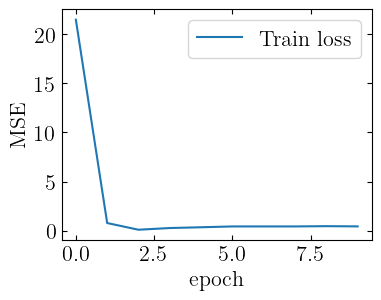

In [ ]:
fig, (ax1) = plt.subplots(1, 1, figsize=(4, 3))
ax1.plot(history["loss"], label="Train loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("MSE")
ax1.legend();

In [ ]:
def eval_rollout_phnn(idx=0):
    model.eval()
    x_seq = x_test_batch
    y_seq = y_test_batch
    m_seq = mask_test_batch
    V_seq = V_test

    with torch.no_grad():
        x_b  = x_seq[idx:idx+1]            # (1, T, 1)
        y_b  = y_seq[idx:idx+1]            # (1, T, 2)

        I_phys   = x_b[:, :, 0] * stats['I'][1] + stats['I'][0]         # Denormalize current (1, T)
        ocv_phys = y_b[:, :, 1] * stats['ocv'][1] + stats['ocv'][0]     # Denormalize OCV

        x0 = torch.zeros(1, 2)
        V_pred_phys = ph_rollout_soc(model, x0, I_phys, ocv_phys, dt=DT, Q_0=0)

    V_pred = V_pred_phys.squeeze(0).numpy()     # (T,)
    V_true = V_seq[idx]                         # (T,)
    valid  = m_seq[idx].numpy().astype(bool)    # (T,)
    t      = np.arange(x_seq.shape[1]) * DT

    # SOC from current state
    Q_0=0
    Q  = x[:, 0]                 # (B,)  charge remaining
    soc = (Q_0 + Q) / model.Q_n  # (B,)  Q is negative (discharge)
    soc = soc.clamp(0.0, 1.0)   # safety clip
    # Learned parameters are single scalars — repeat for plotting
    params = model(soc)          # (B, 3)
    R0 = params[:, 0]
    R1 = params[:, 1]
    C1 = params[:, 2]

    return V_pred, V_true, I_phys, t, valid, R0, R1, C1, Q

0.02122591808438301 0.01711651124060154 1.9616869688034058


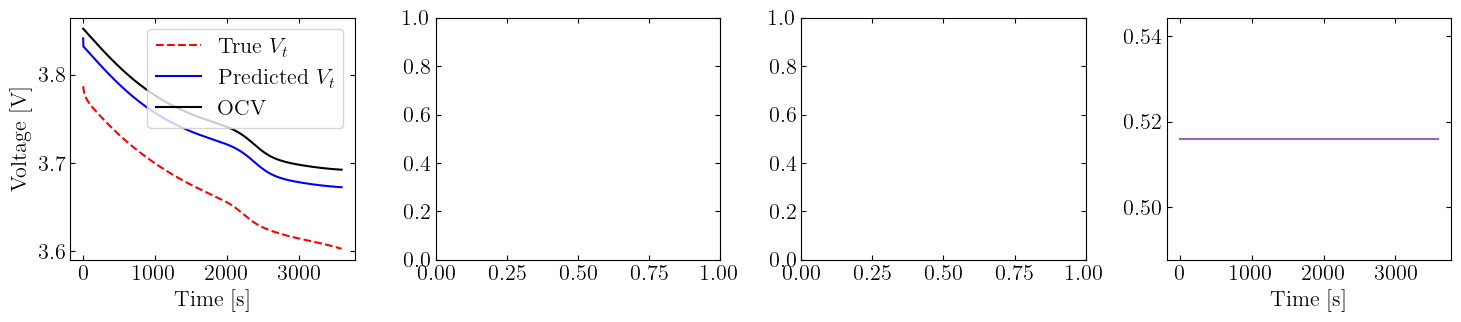

In [ ]:
idx = 0
V_pred, V_true, I_phys, t, valid, R0, R1, C1, Q = eval_rollout_phnn(idx)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))

axes[0].plot(t[valid], V_true[valid], 'r--', label=r'True $V_t$')
axes[0].plot(t[valid], V_pred[valid], 'b-',  label=r'Predicted $V_t$')
axes[0].plot(t[valid], ocv_test[idx][valid], 'k-', label=r'OCV')
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Voltage [V]")
axes[0].legend()

print(R0[0].item(), R1[0].item(), C1[0].item())

axes[3].plot(t, I_phys[0, :], color='tab:purple', label=r'RC time constant $\tau$ [s]')
axes[3].set_xlabel("Time [s]")

fig.tight_layout()